# **Lecture 13: Introduction to ODEs & Euler's Method**

**Date:** Friday, 06-02-2026

**Unit:** 2 (Differential Equations)

**Topic:** Introduction to ODEs: Euler’s Method implementation in Python

-------

## **1. Introduction**

In Unit 1, we dealt with static numbers (roots, integrals, errors). In **Unit 2**, we move to **dynamic systems**—things that change over time.

Almost every problem in Astrophysics is described by a **Differential Equation**:

* **Planetary Orbits:** Newton's Laws ($\vec{F} = m\vec{a}$) are second-order ODEs.
* **Stellar Structure:** Hydrostatic equilibrium ($\frac{dP}{dr} = -\rho g$) is a system of ODEs.
* **Radioactive Decay:** The heating source of planets ($\frac{dN}{dt} = -\lambda N$).

An **Ordinary Differential Equation (ODE)** involves functions of a single independent variable (usually time,  $t$).

Our goal is to find the function $y(t)$ given its rate of change $f(t, y)$:

$$\frac{dy}{dt} = f(t, y)$$

Subject to an **Initial Value**  $y(t_0) = y_0$.

---

## **2. Euler's Method: The Simplest Solver**

### **2.1 The Concept**

Euler's Method is the "first-order" approximation. It uses the definition of the derivative:

$$\frac{dy}{dt} \approx \frac{y(t+h) - y(t)}{h}$$

Rearranging this gives us the algorithm to step forward in time by a small step $h$:
$$y(t+h) \approx y(t) + h \cdot f(t, y)$$

Or in iterative notation:

$$y_{n+1} = y_n + h \cdot f(t_n, y_n)$$

### **2.2 Geometric Interpretation**

Imagine you are walking on a curve, but you are blindfolded. You only know your current position and the **slope** of the ground (the derivative).

1. Look at the slope at your feet.
2. Take a small step  in that direction.
3. Stop, look at the new slope, and repeat.

**Problem:** If the curve bends while you are taking your step, you will overshoot or undershoot. This is the **Truncation Error** of Euler's method.

---

## **3. Implementing Euler's Method in Python**

Let's solve the classic **Radioactive Decay** problem.
$$\frac{dN}{dt} = -\lambda N$$

* $N$: Number of atoms
* $\lambda$: Decay constant
* **Analytical Solution:** $N(t) = N_0 e^{-\lambda t}$

### **3.1 First Principles Implementation**

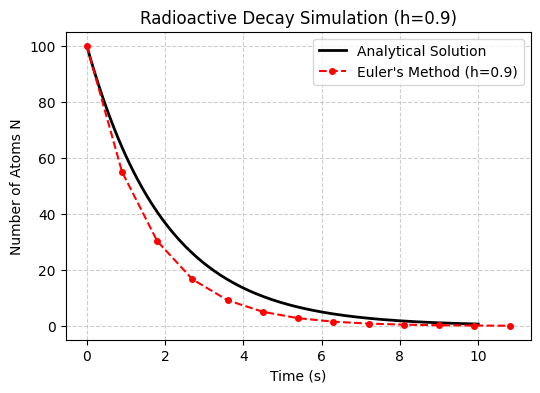

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Derivative Function f(t, y)
def decay_rate(t, N, decay_const):
    """
    Returns dN/dt = -lambda * N
    """
    return -decay_const * N

# 2. Euler's Method Solver
def euler_method(func, y0, t0, t_end, h, params):
    """
    Solves ODE using Euler's method.

    Parameters:
    func   : The derivative function f(t, y, params)
    y0     : Initial value of y
    t0     : Initial time
    t_end  : End time
    h      : Step size
    params : Extra parameters for the derivative function

    Returns:
    t_values : Array of time steps
    y_values : Array of solution values
    """
    # Create time array
    t_values = np.arange(t0, t_end + h, h) # +h to include endpoint

    # Initialize solution array
    y_values = np.zeros(len(t_values))
    y_values[0] = y0

    # Loop over time steps
    for i in range(1, len(t_values)):
        # Current values
        t_curr = t_values[i-1]
        y_curr = y_values[i-1]

        # Calculate slope
        slope = func(t_curr, y_curr, params)

        # Euler step: y_new = y_old + h * slope
        y_values[i] = y_curr + h * slope

    return t_values, y_values

# 3. System Parameters
N0 = 100.0       # Initial atoms
lambda_val = 0.5 # Decay constant
h_step = 0.9     # Step size (try changing this to 1.0 or 0.01)
t_start = 0.0
t_stop = 10.0

# 4. Run Simulation
t_num, N_num = euler_method(decay_rate, N0, t_start, t_stop, h_step, lambda_val)

# 5. Compare with Analytical Solution
t_ana = np.linspace(t_start, t_stop, 200)
N_ana = N0 * np.exp(-lambda_val * t_ana)

# 6. Plotting
plt.figure(figsize=(6, 4))
plt.plot(t_ana, N_ana, 'k-', linewidth=2, label='Analytical Solution')
plt.plot(t_num, N_num, 'ro--', markersize=4, label=f"Euler's Method (h={h_step})")

plt.title(f"Radioactive Decay Simulation (h={h_step})")
plt.xlabel("Time (s)")
plt.ylabel("Number of Atoms N")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---

## **4. Error Analysis**

Euler's method is a First-Order Method. This means the error per step is proportional to $h^2$, but the global error (accumulated over time) is proportional to $h$.

If you halve the step size ($h \to h/2$), the error is cut in half. (Advanced methods like RK4 cut the error by factor of 16 or more!).

Let's visualize the error accumulation.

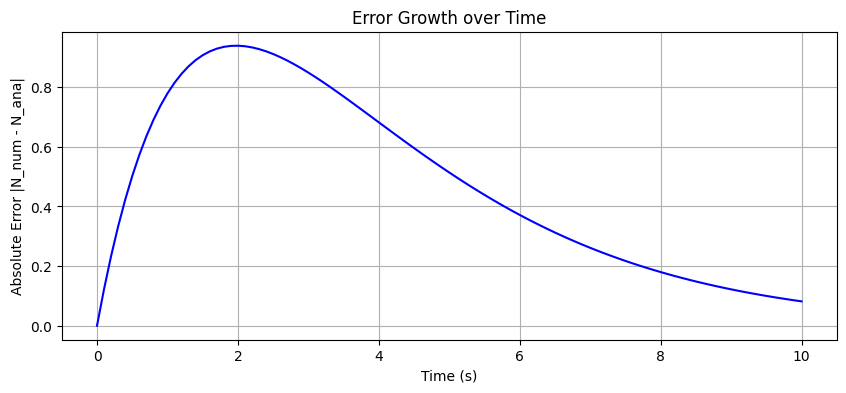

Max Error: 0.93935 atoms


In [ ]:
# Calculate absolute error at each step
# We need to compute analytical values at the specific time steps used by Euler
N_analytical_at_steps = N0 * np.exp(-lambda_val * t_num)
errors = np.abs(N_num - N_analytical_at_steps)

plt.figure(figsize=(10, 4))
plt.plot(t_num, errors, 'b-')
plt.title("Error Growth over Time")
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error |N_num - N_ana|")
plt.grid(True)
plt.show()

print(f"Max Error: {np.max(errors):.5f} atoms")

---

## **5. Astrophysics Application: Simple Harmonic Oscillator (SHO)**

In astrophysics, we often see oscillations (pulsating stars, molecular vibrations).
The equation for a spring (or a pendulum) is:
$$\frac{d^2x}{dt^2} = -\omega^2 x$$

This is a **Second-Order ODE**. To solve it with Euler's method, we must split it into **two First-Order ODEs**:

1. Velocity is the derivative of position: $\frac{dx}{dt} = v$
2. Acceleration is the derivative of velocity: $\frac{dv}{dt} = -\omega^2 x$

### **Vectorized Euler Implementation**

We can store $y = [x, v]$ as a vector and solve them simultaneously.

[  0.        -39.4784176]
[ -0.03947842 -39.4784176 ]
[ -0.07895684 -39.47685906]
[ -0.11843369 -39.47374197]
[ -0.15790744 -39.46906639]
[ -0.1973765  -39.46283246]
[ -0.23683934 -39.45504035]
[ -0.27629438 -39.4456903 ]
[ -0.31574007 -39.43478264]
[ -0.35517485 -39.42231772]
[ -0.39459717 -39.40829598]
[ -0.43400546 -39.39271791]
[ -0.47339818 -39.37558406]
[ -0.51277376 -39.35689505]
[ -0.55213066 -39.33665155]
[ -0.59146731 -39.31485431]
[ -0.63078216 -39.29150411]
[ -0.67007367 -39.26660183]
[ -0.70934027 -39.24014838]
[ -0.74858042 -39.21214475]
[ -0.78779256 -39.18259198]
[ -0.82697516 -39.15149118]
[ -0.86612665 -39.11884351]
[ -0.90524549 -39.0846502 ]
[ -0.94433014 -39.04891254]
[ -0.98337905 -39.01163188]
[ -1.02239069 -38.97280963]
[ -1.06136349 -38.93244726]
[ -1.10029594 -38.89054631]
[ -1.13918649 -38.84710837]
[ -1.1780336  -38.80213509]
[ -1.21683573 -38.75562819]
[ -1.25559136 -38.70758944]
[ -1.29429895 -38.65802068]
[ -1.33295697 -38.6069238 ]
[ -1.37156389 -38.5543

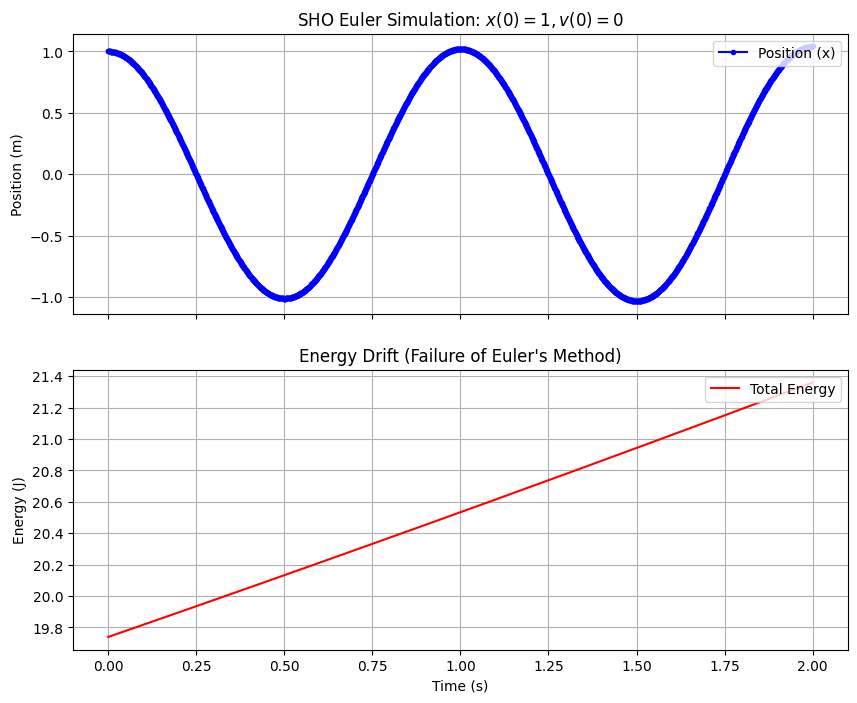

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Modified Euler's Method Solver to handle vector y0
def euler_method(func, y0, t0, t_end, h, params):
    """
    Solves ODE using Euler's method, supporting scalar or vector y0.

    Parameters:
    func   : The derivative function f(t, y, params)
    y0     : Initial value(s) of y (can be a scalar or a numpy array)
    t0     : Initial time
    t_end  : End time
    h      : Step size
    params : Extra parameters for the derivative function

    Returns:
    t_values : Array of time steps
    y_values : Array of solution values (2D if y0 is vector, 1D if y0 is scalar)
    """
    t_values = np.arange(t0, t_end + h, h)

    # Determine if y0 is a scalar or a vector and initialize y_values accordingly
    if np.isscalar(y0):
        y_values = np.zeros(len(t_values))
    else:
        # y0 is an array, so y_values needs to be 2D
        y_values = np.zeros((len(t_values), len(y0)))

    y_values[0] = y0

    for i in range(1, len(t_values)):
        t_curr = t_values[i-1]
        y_curr = y_values[i-1]

        slope = func(t_curr, y_curr, params)
        print(slope)

        y_values[i] = y_curr + h * slope

    return t_values, y_values

def sho_derivatives(t, y_vec, omega):
    """
    Returns [dx/dt, dv/dt]
    y_vec[0] is x (position)
    y_vec[1] is v (velocity)
    """
    x = y_vec[0]
    v = y_vec[1]

    dxdt = v
    dvdt = -(omega**2) * x

    return np.array([dxdt, dvdt])

# Parameters
omega = 2.0 * np.pi # Frequency 1 Hz
y0_vec = np.array([1.0, 0.0]) # Start at x=1, v=0 (release from rest)
t_max = 2.0
h_sho = 0.001

# Call the (now fixed) euler_method
t_sho, y_sho = euler_method(sho_derivatives, y0_vec, 0.0, t_max, h_sho, omega)

# Extract x and v
x_vals = y_sho[:, 0]
v_vals = y_sho[:, 1]

# Plot
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Position Plot
ax[0].plot(t_sho, x_vals, 'b.-', label='Position (x)')
ax[0].set_ylabel('Position (m)')
ax[0].set_title(r'SHO Euler Simulation: $x(0)=1, v(0)=0$')
ax[0].grid(True)
ax[0].legend(loc="upper right")

# Energy Plot (Conservation Check)
# Energy E = 0.5*k*x^2 + 0.5*m*v^2. Let's assume k=m*omega^2, m=1.
E_total = 0.5 * (omega**2) * x_vals**2 + 0.5 * v_vals**2
ax[1].plot(t_sho, E_total, 'r-', label='Total Energy')
ax[1].set_ylabel('Energy (J)')
ax[1].set_xlabel('Time (s)')
ax[1].grid(True)
ax[1].legend(loc="upper right")

# Highlight the issue
ax[1].set_title("Energy Drift (Failure of Euler's Method)")

plt.show()

**Critical Observation:** Notice how the Energy increases over time? The amplitude of the oscillation grows!

* Euler's Method is **unstable** for oscillatory problems (it adds fake energy to the system).
* This is why we need **Symplectic Integrators** or **Runge-Kutta** (Lecture 14).

---

## **6. Student Exercises**

### **Problem 1: Falling Object with Air Resistance**

**Physics:** An object falls under gravity  with air drag proportional to velocity squared ($v^2$).

$$\frac{dv}{dt} = g - C_d v^2$$
Where $C_d$ is the drag coefficient.


**Task:**

1. Define the derivative function for a falling rock on Mars ($g=3.71, C_d=0.1$).
2. Use Euler's method to find the velocity $v(t)$ starting from rest ($v=0$).
3. Simulate for 10 seconds.
4. **Identify Terminal Velocity:** At what speed does the velocity stop changing?

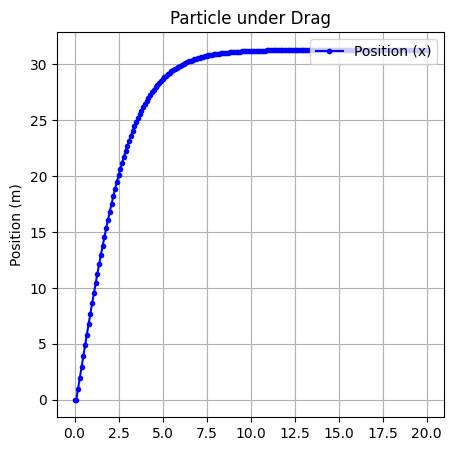

In [ ]:
def euler_method(f, y0, t0, tend, h, params):
  """
  Return: y
  """

  t = np.arange(t0, tend+h, h)

  y = np.zeros(len(t))

  for i in range(1, len(y)-1):
    t_curr = t[i]
    y_curr = y[i]
    slope = f(t_curr, y_curr, params)
    y[i+1] = y[i] + h*slope

  return [t, y]


def fall_rate(t, v, params):
    """
    Returns [dy/dt, dv/dt]
    y_vec[0] is y (position)
    y_vec[1] is v (velocity)
    """
    g = params[0]
    Cd = params[1]

    dvdt = g - (Cd) * v**2

    return dvdt


# Parameters
Cd = 0.01
g = 9.8
v = 0  #
t_max = 20
h_fall = 0.1
params = np.array([g, Cd])

# Call the (now fixed) euler_method
t_sho, v_vals = euler_method(fall_rate, v, 0.0, t_max, h_fall, params)

# print(y_vals, v_vals)
# Plot velocity vs time

# Plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Position Plot
ax.plot(t_sho, v_vals, 'b.-', label='Position (x)')
ax.set_ylabel('Position (m)')
ax.set_title(r'Particle under Drag')
ax.grid(True)
ax.legend(loc="upper right")
plt.show()


### **Problem 2: Population Growth (Stellar Formation)**

**Physics:** The rate of star formation is proportional to the available gas mass $M_g$.

$$\frac{dM_g}{dt} = -k M_g$$

However, let's assume gas is being replenished at a constant rate $R$.
$$\frac{dM_g}{dt} = R - k M_g$$

**Task:**

1. Solve this ODE for $M_g(0) = 0$.
2. Set $R = 10$ and $k = 0.5$.
3. Does the mass explode to infinity or settle at a steady state?

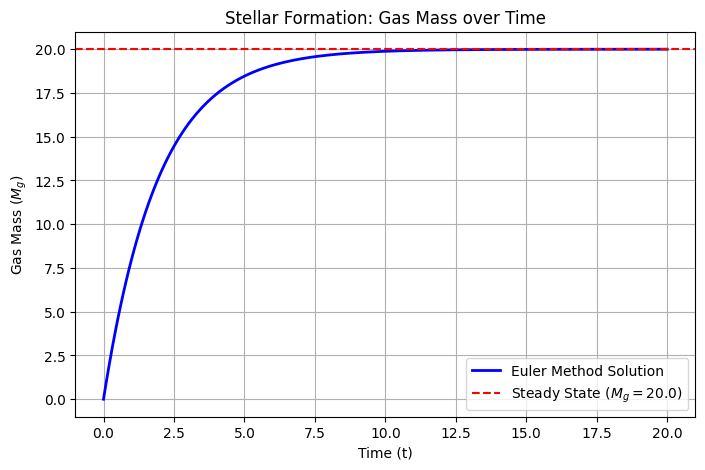

In [ ]:
# Student Code Area 2
# Implement and solve

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
R = 10.0      # Replenishment rate
k = 0.5       # Star formation rate constant
M_g0 = 0.0    # Initial gas mass at t = 0
dt = 0.1      # Time step size
t_max = 20.0  # Maximum time to simulate

# --- Setup Arrays ---
t = np.arange(0, t_max + dt, dt) # Time array
M_g = np.zeros(len(t))           # Array to store gas mass
M_g[0] = M_g0                    # Apply initial condition

# --- Euler Method ---
# Formula: M_g(t + dt) = M_g(t) + dt * (R - k * M_g(t))
for i in range(1, len(t)):
    dMg_dt = R - k * M_g[i-1]
    M_g[i] = M_g[i-1] + dMg_dt * dt

# --- Plotting ---
plt.figure(figsize=(8, 5))
plt.plot(t, M_g, label='Euler Method Solution', color='blue', linewidth=2)

# Plot the theoretical steady state for reference
steady_state_value = R / k
plt.axhline(y=steady_state_value, color='red', linestyle='--',
            label=f'Steady State ($M_g = {steady_state_value}$)')

plt.xlabel('Time (t)')
plt.ylabel('Gas Mass ($M_g$)')
plt.title('Stellar Formation: Gas Mass over Time')
plt.legend()
plt.grid(True)
plt.show()

To fully understand how the gas mass behaves over time, we can solve the differential equation analytically. This gives us the exact mathematical formula that the Euler method was approximating.

1. Setting up the Differential EquationWe start with the given ordinary differential equation (ODE) representing the change in gas mass over time:$$\frac{dM_g}{dt} = R - k M_g$$
Where:$M_g$ is the available gas mass.$R$ is the constant replenishment rate.$k$ is the star formation rate constant.

2. Solving the ODE: This is a first-order linear ordinary differential equation. We can solve it using the Separation of Variables method or an Integrating Factor. Let's use separation of variables.

Step A: Rearrange the equation: Group the $M_g$ terms on one side and the $t$ terms on the other:$$\frac{dM_g}{R - k M_g} = dt$$

Step B: Integrate both sides$$\int \frac{1}{R - k M_g} dM_g = \int dt$$
To integrate the left side, we use a standard natural logarithm rule. Remember to divide by the inner derivative ($-k$):$$-\frac{1}{k} \ln|R - k M_g| = t + C_1$$

Step C: Solve for $M_g$Multiply both sides by $-k$:$$\ln|R - k M_g| = -kt - k C_1$$Take the exponential of both sides to remove the natural logarithm:$$R - k M_g = e^{-kt - k C_1}$$We can rewrite $e^{-kt - k C_1}$ as $C e^{-kt}$ (where $C$ is a new combined constant):$$R - k M_g = C e^{-kt}$$
$$k M_g = R - C e^{-kt}$$ $$ M_g(t) = \frac{R}{k} - \frac{C}{k} e^{-kt}$$

Let's redefine $-\frac{C}{k}$ as a simpler constant $A$:$$M_g(t) = \frac{R}{k} + A e^{-kt}$$

3. Applying the Initial Condition
We are given that the initial gas mass is zero: $M_g(0) = 0$. We plug $t = 0$ and $M_g = 0$ into our general solution to find the constant $A$.$$0 = \frac{R}{k} + A e^{-k(0)}$$$$0 = \frac{R}{k} + A (1)$$$$A = -\frac{R}{k}$$Substitute $A$ back into the equation to get the particular solution:$$M_g(t) = \frac{R}{k} - \frac{R}{k} e^{-kt}$$$$M_g(t) = \frac{R}{k} \left( 1 - e^{-kt} \right)$$

4. System Behavior: Plugging in the Values
Now, we substitute the specific values given in your task: $R = 10$ and $k = 0.5$.$$M_g(t) = \frac{10}{0.5} \left( 1 - e^{-0.5t} \right)$$
$$M_g(t) = 20 \left( 1 - e^{-0.5t} \right)$$Analyzing the behavior over time:At $t = 0$: $e^{0} = 1$. The mass is $20(1 - 1) = 0$.As $t$ grows larger: The term $e^{-0.5t}$ becomes smaller and smaller, approaching zero.As $t \to \infty$: The $e^{-0.5t}$ term vanishes entirely. The equation simplifies to $M_g = 20(1 - 0) = 20$.

Conclusion: The mass does not explode to infinity. Because of the exponential decay term ($-e^{-kt}$), the gas mass settles smoothly at a steady-state limit of 20.

## **7. Runge-Kutta 4th Order Method (RK4)**

Euler's method is simple but often inaccurate, especially for larger step sizes or oscillatory systems.

The Runge-Kutta methods are a family of numerical integrators that achieve higher accuracy by evaluating the derivative function at several points within each step.

The most common is the **4th Order Runge-Kutta method (RK4)**. It calculates four 'slopes' or 'estimates' within each step to get a more accurate average slope:

1. $k_1 = h f(t_n, y_n)$
2. $k_2 = h f(t_n + h/2, y_n + k_1/2)$
3. $k_3 = h f(t_n + h/2, y_n + k_2/2)$
4. $k_4 = h f(t_n + h, y_n + k_3)$
 Then, the next value $y_{n+1}$ is computed as:

 $y_{n+1} = y_n + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)$

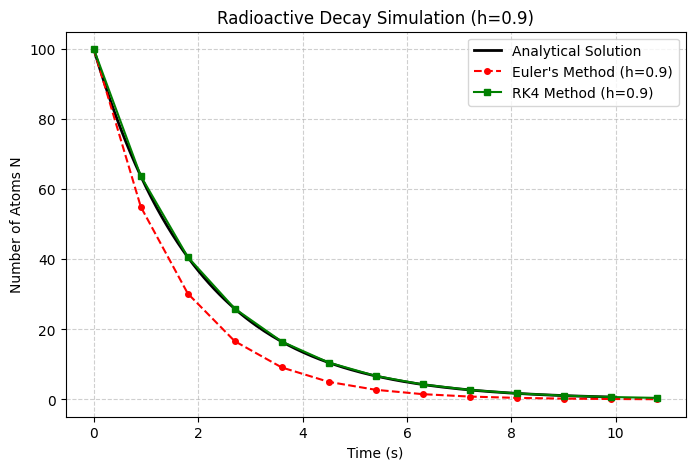

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# RK4 Method Solver
def rk4_method(func, y0, t0, t_end, h, params):
    """
    Solves ODE using the 4th Order Runge-Kutta method.

    Parameters:
    func   : The derivative function f(t, y, params)
    y0     : Initial value(s) of y (scalar or numpy array)
    t0     : Initial time
    t_end  : End time
    h      : Step size
    params : Extra parameters for the derivative function

    Returns:
    t_values : Array of time steps
    y_values : Array of solution values
    """
    t_values = np.arange(t0, t_end + h, h)

    if np.isscalar(y0):
        y_values = np.zeros(len(t_values))
    else:
        y_values = np.zeros((len(t_values), len(y0)))

    y_values[0] = y0

    for i in range(1, len(t_values)):
        t_curr = t_values[i-1]
        y_curr = y_values[i-1]

        # RK4 coefficients
        k1 = h * func(t_curr, y_curr, params)
        k2 = h * func(t_curr + 0.5 * h, y_curr + 0.5 * k1, params)
        k3 = h * func(t_curr + 0.5 * h, y_curr + 0.5 * k2, params)
        k4 = h * func(t_curr + h, y_curr + k3, params)

        # RK4 step
        y_values[i] = y_curr + (k1 + 2*k2 + 2*k3 + k4) / 6.0

    return t_values, y_values


def decay_rate(t, N, decay_const):
    """
    Returns dN/dt = -lambda * N
    """
    return -decay_const * N

# 2. System Parameters
N0 = 100.0       # Initial atoms
lambda_val = 0.5 # Decay constant
h_step = 0.9     # Step size (same as Euler's for comparison)
t_start = 0.0
t_stop = 10.0

# 3. Run RK4 Simulation
t_rk4, N_rk4 = rk4_method(decay_rate, N0, t_start, t_stop, h_step, lambda_val)

# 4. Compare with Analytical Solution
t_ana_plot = np.linspace(t_start, t_stop, 200) # For smooth analytical curve
N_ana_plot = N0 * np.exp(-lambda_val * t_ana_plot)

# 5. Get Euler's method results for plotting comparison
# The euler_method function and its results (t_num, N_num) are expected to be

# For self-containment, the euler_method is redefined here.
def euler_method(func, y0, t0, t_end, h, params):
    t_values = np.arange(t0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y0
    for i in range(1, len(t_values)):
        t_curr = t_values[i-1]
        y_curr = y_values[i-1]
        slope = func(t_curr, y_curr, params)
        y_values[i] = y_curr + h * slope
    return t_values, y_values

t_num, N_num = euler_method(decay_rate, N0, t_start, t_stop, h_step, lambda_val)


# 6. Plotting Comparison
plt.figure(figsize=(8, 5))
plt.plot(t_ana_plot, N_ana_plot, 'k-', linewidth=2, label='Analytical Solution')
plt.plot(t_num, N_num, 'ro--', markersize=4, label=f"Euler's Method (h={h_step})")
plt.plot(t_rk4, N_rk4, 'gs-', markersize=4, label=f"RK4 Method (h={h_step})")

plt.title(f"Radioactive Decay Simulation (h={h_step})")
plt.xlabel("Time (s)")
plt.ylabel("Number of Atoms N")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## **8. Error Analysis for RK4**

RK4 is a Fourth-Order Method. This means the error per step is proportional to $h^5$, and the global error (accumulated over time) is proportional to $h^4$.

If you halve the step size ($h \to h/2$), the error is cut by a factor of $2^4 = 16$.



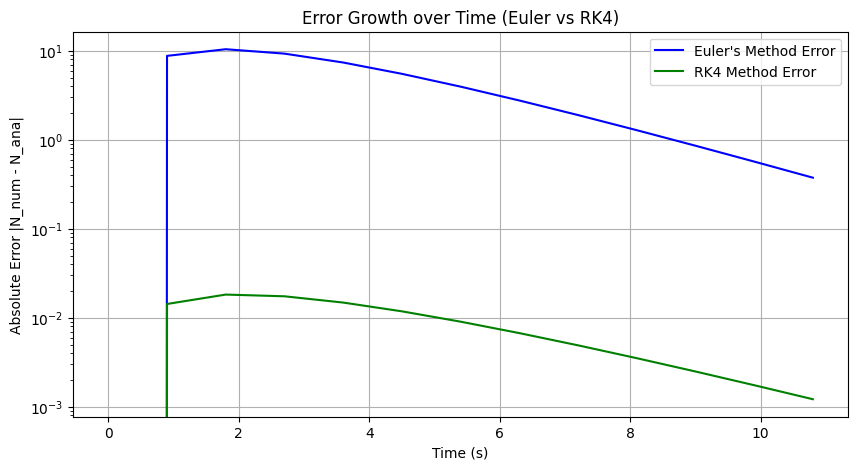

Max Error (Euler): 10.40697 atoms
Max Error (RK4): 0.01823 atoms


In [ ]:
# Calculate absolute error at each step for RK4
N_analytical_at_rk4_steps = N0 * np.exp(-lambda_val * t_rk4)
errors_rk4 = np.abs(N_rk4 - N_analytical_at_rk4_steps)

# Calculate absolute error at each step for Euler (re-using variables)
N_analytical_at_euler_steps = N0 * np.exp(-lambda_val * t_num)
errors_euler = np.abs(N_num - N_analytical_at_euler_steps)

plt.figure(figsize=(10, 5))
plt.plot(t_num, errors_euler, 'b-', label="Euler's Method Error")
plt.plot(t_rk4, errors_rk4, 'g-', label="RK4 Method Error")
plt.title("Error Growth over Time (Euler vs RK4)")
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error |N_num - N_ana|")
plt.legend()
plt.grid(True)
plt.yscale('log') # Use a log scale to better visualize small RK4 errors
plt.show()

print(f"Max Error (Euler): {np.max(errors_euler):.5f} atoms")
print(f"Max Error (RK4): {np.max(errors_rk4):.5f} atoms")


### Observation:

Notice how significantly smaller the error for RK4 is compared to Euler's method, even with the same relatively large step size! This demonstrates the power of higher-order methods.



## Problem 1: Orbital Dynamics (The Comet's Path)Physics:

According to Newton's law of universal gravitation, the acceleration of a comet orbiting a massive star is inversely proportional to the square of its distance. Because the comet moves in two dimensions (x and y), this 2nd-order differential equation must be broken down into a system of four 1st-order ODEs to be solved via RK4.Equations:Let $r = \sqrt{x^2 + y^2}$ be the distance to the star.

The system of equations is:Velocity in x: $$\frac{dx}{dt} = v_x$$Acceleration in x: $$\frac{dv_x}{dt} = -\frac{GMx}{r^3}$$Velocity in y: $$\frac{dy}{dt} = v_y$$Acceleration in y: $$\frac{dv_y}{dt} = -\frac{GMy}{r^3}$$

Task:
1. Set the standard gravitational parameter GM = 1.Set initial conditions for a highly elliptical orbit: x(0) = 1, y(0) = 0, $v_x(0) = 0$, $v_y(0) = 0.3$.

2. Use RK4 to simulate the comet's position over time and plot the orbit.

3. Does the comet escape, or does it form a closed ellipse?


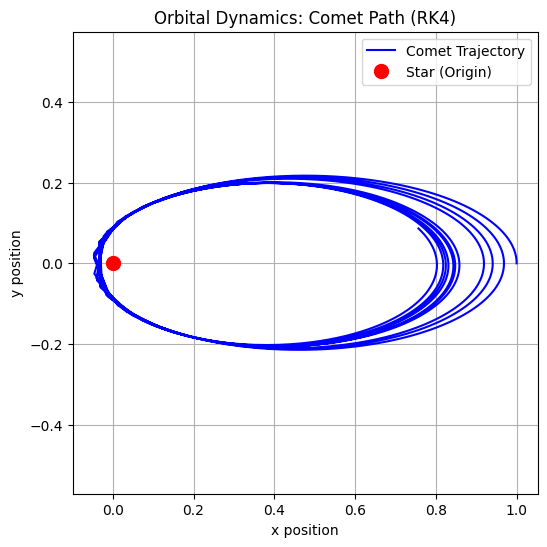

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Define the System of ODEs ---
def comet_orbit(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    GM = 1.0  # Standard gravitational parameter

    dxdt = vx
    dydt = vy
    dvxdt = -GM * x / r**3
    dvydt = -GM * y / r**3

    return [dxdt, dydt, dvxdt, dvydt]

# --- Setup and Initial Conditions ---
# state = [x, y, v_x, v_y]
initial_state = [1.0, 0.0, 0.0, 0.3]

# Time span for the simulation (0 to 20 time units)
t_span = (0, 20)
# Generate evaluation points for a smooth plot
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# --- Solve using RK4 (RK45 in SciPy) ---
solution = solve_ivp(comet_orbit, t_span, initial_state, method='RK45', t_eval=t_eval)

# Extract x and y coordinates from the solution
x_vals = solution.y[0]
y_vals = solution.y[1]

# --- Plotting ---
plt.figure(figsize=(6, 6))
plt.plot(x_vals, y_vals, color='blue', label='Comet Trajectory')
plt.plot(0, 0, 'ro', markersize=10, label='Star (Origin)') # Mark the star

plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Orbital Dynamics: Comet Path (RK4)')
plt.axis('equal') # Ensure x and y scales are equal so the orbit shape is accurate
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
from IPython.display import HTML

# --- 1. Define and Solve the ODE ---
def comet_orbit(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    GM = 1.0
    return [vx, vy, -GM * x / r**3, -GM * y / r**3]

t_eval = np.linspace(0, 20, 500)
solution = solve_ivp(comet_orbit, (0, 20), [1.0, 0.0, 0.0, 0.3], method='RK45', t_eval=t_eval)

x_vals, y_vals = solution.y[0], solution.y[1]

# --- 2. Setup the Plot ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-0.8, 0.8)
ax.grid(True)
ax.set_title('Orbital Dynamics: Comet Animation')
ax.set_xlabel('x position')
ax.set_ylabel('y position')

ax.plot(0, 0, 'ro', markersize=10, label='Star')

trail, = ax.plot([], [], 'b-', lw=1.5, alpha=0.5, label='Path')
comet, = ax.plot([], [], 'bo', markersize=6, label='Comet')
ax.legend(loc="upper right")

# --- 3. Animate ---
def init():
    trail.set_data([], [])
    comet.set_data([], [])
    return trail, comet

def update(frame):
    trail.set_data(x_vals[:frame], y_vals[:frame])
    comet.set_data([x_vals[frame]], [y_vals[frame]])
    return trail, comet

ani = FuncAnimation(fig, update, frames=len(t_eval), init_func=init, blit=True, interval=20)

# --- 4. Render in Google Colab ---
# Close the static plot so it doesn't show up twice
plt.close()

# Display the animation with interactive HTML controls
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

2. System Behavior: Escape vs. Closed EllipseThe comet forms a highly eccentric, closed ellipse. It does not escape the star's gravitational pull.Here is the physics breakdown of why:An orbit's shape is determined by its specific orbital energy ($\varepsilon$), which is the sum of its kinetic and potential energy:$$\varepsilon = \frac{v^2}{2} - \frac{GM}{r}$$

Using your initial conditions ($r = 1$, $v = 0.3$, $GM = 1$):$$\varepsilon = \frac{0.3^2}{2} - \frac{1}{1}$$$$\varepsilon = 0.045 - 1 = -0.955$$

Because the total energy is negative, the comet does not have enough kinetic energy to overcome the star's gravitational potential well.
It is bound to the star, resulting in a closed elliptical loop. If the energy were greater than or equal to zero, it would follow a parabolic or hyperbolic escape trajectory.

## Problem 2: Stellar Structure (The Lane-Emden Equation)Physics:

To understand the deep interior of a star, astrophysicists use the Lane-Emden equation. It describes the density profile of a self-gravitating sphere of gas (a polytrope) in hydrostatic equilibrium.

Equations:The Lane-Emden equation is a 2nd-order non-linear ODE:$$\frac{1}{\xi^2} \frac{d}{d\xi} \left( \xi^2 \frac{d\theta}{d\xi} \right) = -\theta^n$$Where $\xi$ is the dimensionless radius, $\theta$ is the dimensionless density, and n is the polytropic index (dictating the gas properties).

To solve this with RK4, we define a new variable $\phi = \frac{d\theta}{d\xi}$ to create a system of two 1st-order ODEs:$$\frac{d\theta}{d\xi} = \phi$$$$\frac{d\phi}{d\xi} = -\theta^n - \frac{2\phi}{\xi}$$

Task:
1. Set the initial conditions at the core of the star ($\xi \approx 0$): $\theta(0) = 1$ and $\phi(0) = 0$. (Note: Because of the division by zero at $\xi = 0$, you must start the numerical integration at a very small number like $\xi = 0.00001$).

2. Solve the system for a non-relativistic degenerate gas where n = 1.5 (similar to a white dwarf).

3. The surface of the star is reached when the density drops to zero ($\theta = 0$). At what dimensionless radius $\xi$ does this star end?


## Problem 3: Cosmological Expansion (The Friedmann Equation)

The Friedmann equation dictates how the scale
factor of the universe, $a(t)$, changes over time depending on the density of matter and dark energy.Equations:For a simplified, flat universe containing only matter and a cosmological constant (dark energy), the expansion rate is given by:$$\frac{da}{dt} = H_0 \sqrt{\frac{\Omega_m}{a} + \Omega_\Lambda a^2}$$Where:$a$ is the scale factor (where present day $a = 1$).$H_0$ is the Hubble constant.$\Omega_m$ is the matter density parameter.

$\Omega_\Lambda$ is the dark energy density parameter.

Task:Set $H_0 = 1$ (to measure time in terms of the Hubble time).Set our universe's parameters: $\Omega_m = 0.3$ and $\Omega_\Lambda = 0.7$.Start the universe at a small scale factor $a(0) = 0.001$.Use RK4 to project the scale factor $a(t)$ into the future. Identify the transition point in the curve where the universe shifts from decelerating (matter-dominated) to accelerating (dark-energy dominated).